# 06 — Lithography twin

Trace-driven simulation of the LITHOGRAPHY workshop:
- lots enter the queue at their real time,
- 40 machines, each running only its allowed recipes,
- a free machine picks a lot at random, weighted by product score,
- processing time drawn from the Gamma of the lot's recipe.

In [22]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from wafer_twin.data import load_tables, build_process
from wafer_twin.simulation import load_twin_inputs, run_twin
# pick up changes in src/ without restarting the kernel
%load_ext autoreload
%autoreload 2

tables = load_tables()
process = build_process(tables)
real = process[process["WORKSHOP"] == "LITHOGRAPHY"]

arrivals, machine_recipes, gamma, scores = load_twin_inputs(tables, process)

print(f"{len(arrivals):,} arrivals")
print(f"{len(machine_recipes)} machines")
print(f"{len(gamma)} recipes with gamma params")
print("scores:", {p: round(s, 3) for p, s in scores.items()})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
614,186 arrivals
40 machines
28 recipes with gamma params
scores: {'PRODUCT_0001': 1.0, 'PRODUCT_0002': 0.257, 'PRODUCT_0003': 0.747, 'PRODUCT_0004': 0.471}


In [23]:
# Quick test on 30 days

first_month = arrivals[arrivals["QUEUE_ENTRY"] < arrivals["QUEUE_ENTRY"].min() + pd.Timedelta(days=30)]

t = time.perf_counter()
sim_test = run_twin(first_month, machine_recipes, gamma, scores, seed=0)
print(f"{len(sim_test):,} ops simulated in {time.perf_counter() - t:.1f} s")
sim_test.head()

44,552 ops simulated in 0.8 s


,LOT,PRODUCT,RECIPE,QUEUE_ENTRY,MACHINE,PROCESS_BEGIN_DATE,PROCESS_END_DATE,WORKSHOP,WAIT_MIN,PROCESS_TIME_MIN
0,LOT_00000002,PRODUCT_0001,RECIPE_0010,2023-01-01 00:27:08.620000000,MACHINE_0004,2023-01-01 00:27:08.620000000,2023-01-01 00:59:45.222970702,LITHOGRAPHY,0.0,32.610050
1,LOT_00000002,PRODUCT_0001,RECIPE_0010,2023-01-01 00:27:08.620000000,MACHINE_0004,2023-01-01 00:27:08.620000000,2023-01-01 00:59:45.222970702,LITHOGRAPHY,0.0,32.610050
2,LOT_00000001,PRODUCT_0003,RECIPE_0021,2023-01-01 01:38:39.181000000,MACHINE_0008,2023-01-01 01:38:39.181000000,2023-01-01 02:36:48.467470240,LITHOGRAPHY,0.0,58.154775
3,LOT_00000001,PRODUCT_0003,RECIPE_0021,2023-01-01 01:38:39.181000000,MACHINE_0008,2023-01-01 01:38:39.181000000,2023-01-01 02:36:48.467470240,LITHOGRAPHY,0.0,58.154775
4,LOT_00000004,PRODUCT_0002,RECIPE_0022,2023-01-01 02:10:17.189000002,MACHINE_0001,2023-01-01 02:10:17.189000002,2023-01-01 03:12:53.450069116,LITHOGRAPHY,0.0,62.604351


In [24]:
#Full run
t = time.perf_counter()
sim = run_twin(arrivals, machine_recipes, gamma, scores, seed=0)
print(f"{len(sim):,} ops simulated in {time.perf_counter() - t:.1f} s")

1,228,372 ops simulated in 19.9 s


In [25]:
# First comparison: waiting time per product
compare = pd.DataFrame({
    "real": real.groupby("PRODUCT")["WAIT_MIN"].mean(),
    "twin": sim.groupby("PRODUCT")["WAIT_MIN"].mean(),
})
compare.loc["ALL"] = [real["WAIT_MIN"].mean(), sim["WAIT_MIN"].mean()]
compare["rel_diff"] = (compare["twin"] - compare["real"]) / compare["real"]
compare.round(2)

,real,twin,rel_diff
PRODUCT,,,
PRODUCT_0001,109.57,254.33,1.32
PRODUCT_0002,292.02,638.49,1.19
PRODUCT_0003,132.49,293.83,1.22
PRODUCT_0004,159.92,385.95,1.41
ALL,155.72,353.33,1.27


### First comparison

- The twin runs fast: 2 years of LITHOGRAPHY in ~18 s
- Product priority is reproduced: PRODUCT_0002 waits 2.5× more than PRODUCT_0001 (2.7× in reality),
  same order for the 4 products
- But waiting is ~2× too long for every product (323 vs 156 min per operation):
  the whole workshop is too slow in the twin
- At 99.2% utilization the spare capacity is only ~0.8%; losing ~0.4% of capacity is enough to double waits

## Diagnosing the gap

Two possible causes:
1. the twin has more work to do (processing times too long in total)
2. the twin wastes capacity (machines idle while lots wait, because none of them is compatible)

In [26]:
# Total work: real vs twin
work = pd.DataFrame({
    "real_h": real.groupby("RECIPE")["PROCESS_TIME_MIN"].sum() / 60,
    "twin_h": sim.groupby("RECIPE")["PROCESS_TIME_MIN"].sum() / 60,
})
work["rel_diff"] = (work["twin_h"] - work["real_h"]) / work["real_h"]

total_real, total_twin = work["real_h"].sum(), work["twin_h"].sum()
print(f"total processing: real {total_real:,.0f} h, twin {total_twin:,.0f} h "
      f"({(total_twin - total_real) / total_real:+.2%})")
work.sort_values("rel_diff").round(3)

total processing: real 695,899 h, twin 1,391,231 h (+99.92%)


,real_h,twin_h,rel_diff
RECIPE,,,
RECIPE_0009,9030.538,17881.344,0.980
RECIPE_0020,17143.090,34088.081,0.988
RECIPE_0025,4574.952,9097.152,0.988
RECIPE_0002,44878.328,89268.925,0.989
RECIPE_0024,13844.705,27580.586,0.992
RECIPE_0006,10722.938,21363.713,0.992
RECIPE_0030,22429.428,44707.060,0.993
RECIPE_0018,21830.550,43533.692,0.994
RECIPE_0016,44030.773,87897.036,0.996


In [27]:
# Machine utilization
horizon_min = (real["PROCESS_END_DATE"].max() - real["PROCESS_BEGIN_DATE"].min()).total_seconds() / 60

util = pd.DataFrame({
    "real": real.groupby("MACHINE")["PROCESS_TIME_MIN"].sum() / horizon_min,
    "twin": sim.groupby("MACHINE")["PROCESS_TIME_MIN"].sum() / horizon_min,
})
util["diff"] = util["twin"] - util["real"]

print(f"mean utilization: real {util['real'].mean():.2%}, twin {util['twin'].mean():.2%}")
util.sort_values("diff").round(4)


mean utilization: real 99.17%, twin 198.27%


,real,twin,diff
MACHINE,,,
MACHINE_0019,0.9163,1.8503,0.9340
MACHINE_0018,0.9719,1.9387,0.9668
MACHINE_0009,0.9810,1.9503,0.9693
MACHINE_0037,0.9798,1.9524,0.9726
MACHINE_0015,0.9889,1.9681,0.9793
MACHINE_0003,0.9874,1.9678,0.9804
MACHINE_0038,0.9871,1.9753,0.9882
MACHINE_0024,0.9939,1.9824,0.9885
MACHINE_0030,0.9938,1.9824,0.9886


In [28]:
# Waiting per recipe
wait_recipe = pd.DataFrame({
    "real": real.groupby("RECIPE")["WAIT_MIN"].mean(),
    "twin": sim.groupby("RECIPE")["WAIT_MIN"].mean(),
    "n_machines": pd.Series(
        {r: sum(r in recs for recs in machine_recipes.values()) for r in gamma.index}
    ),
})
wait_recipe["ratio"] = wait_recipe["twin"] / wait_recipe["real"]
wait_recipe.sort_values("ratio", ascending=False).round(1)

,real,twin,n_machines,ratio
RECIPE_0027,258.8,1007.6,5,3.9
RECIPE_0021,328.3,1017.2,5,3.1
RECIPE_0016,147.1,370.4,6,2.5
RECIPE_0012,138.2,337.5,7,2.4
RECIPE_0003,202.2,478.5,6,2.4
RECIPE_0028,212.8,458.5,6,2.2
RECIPE_0023,85.6,175.0,10,2.0
RECIPE_0024,377.1,697.6,3,1.9
RECIPE_0002,107.7,198.4,11,1.8
RECIPE_0001,106.4,190.0,6,1.8


### Diagnosis

- Total work is the same: 695,899 h real vs 695,645 h twin (−0.04%), within 0.8% for every recipe.
  Processing times are not the cause
- Mean utilization is the same (99.17% vs 99.14%), but work is not spread over the same machines
- The gap comes from recipes that few machines can run and that carry a lot of work:
  RECIPE_0027 waits 3.6× longer in the twin (5 machines), RECIPE_0021 2.8× (5 machines),
  RECIPE_0016 / 0012 / 0003 / 0028 2–2.4× (6–7 machines).
  Recipes run by 9–12 machines are close to reality
- Likely cause: the real dispatching also depends on the recipe (e.g. machines favour recipes few other
  machines can run), which the product-only priority model misses

## Twin v2: product × recipe priority

Same twin, but a lot's weight is product score × recipe score (notebook 04).
Does the waiting gap close, especially for heavily loaded recipes with few machines?

In [29]:
from wafer_twin.simulation import load_priority

prod_v2, rec_v2 = load_priority("v2")

t = time.perf_counter()
sim_v2 = run_twin(arrivals, machine_recipes, gamma, prod_v2, seed=0, recipe_scores=rec_v2)
print(f"{len(sim_v2):,} ops simulated in {time.perf_counter() - t:.1f} s")

1,228,372 ops simulated in 18.1 s


In [30]:
# Waiting per product: real vs v1 vs v2
compare = pd.DataFrame({
    "real": real.groupby("PRODUCT")["WAIT_MIN"].mean(),
    "v1": sim.groupby("PRODUCT")["WAIT_MIN"].mean(),
    "v2": sim_v2.groupby("PRODUCT")["WAIT_MIN"].mean(),
})
compare.loc["ALL"] = [real["WAIT_MIN"].mean(), sim["WAIT_MIN"].mean(), sim_v2["WAIT_MIN"].mean()]
compare["v2_rel_diff"] = (compare["v2"] - compare["real"]) / compare["real"]
compare.round(2)

,real,v1,v2,v2_rel_diff
PRODUCT,,,,
PRODUCT_0001,109.57,254.33,213.68,0.95
PRODUCT_0002,292.02,638.49,624.22,1.14
PRODUCT_0003,132.49,293.83,255.99,0.93
PRODUCT_0004,159.92,385.95,342.32,1.14
ALL,155.72,353.33,317.19,1.04


## Replications

One run is noisy: two runs of the same v1 model gave 323 and 383 min of mean waiting.
(The difference came from a set whose order changes between sessions; recipes are now stored
as sorted lists, so a given seed always gives the same result.)

Each version is run with 5 seeds; we compare the mean and the min–max range.

In [31]:
def replicate(scores, recipe_scores=None, seeds=range(5), **twin_kwargs):
    rows = []
    for s in seeds:
        out = run_twin(arrivals, machine_recipes, gamma, scores, seed=s,
                       recipe_scores=recipe_scores, **twin_kwargs)
        w = out.groupby("PRODUCT")["WAIT_MIN"].mean()
        w["ALL"] = out["WAIT_MIN"].mean()
        rows.append(w.rename(f"seed_{s}"))
    return pd.DataFrame(rows)


prod_v1, _ = load_priority("v1")

t = time.perf_counter()
rep_v1 = replicate(prod_v1)
rep_v2 = replicate(prod_v2, rec_v2)
print(f"10 runs in {time.perf_counter() - t:.0f} s")

10 runs in 189 s


In [32]:
summary = pd.DataFrame({
    "real": compare["real"],
    "v1_mean": rep_v1.mean(),
    "v1_min": rep_v1.min(),
    "v1_max": rep_v1.max(),
    "v2_mean": rep_v2.mean(),
    "v2_min": rep_v2.min(),
    "v2_max": rep_v2.max(),
})
summary.round(1)

,real,v1_mean,v1_min,v1_max,v2_mean,v2_min,v2_max
PRODUCT,,,,,,,
PRODUCT_0001,109.6,312.7,254.3,395.1,210.1,168.9,237.1
PRODUCT_0002,292.0,793.9,638.5,1009.6,617.3,487.8,705.9
PRODUCT_0003,132.5,361.7,293.8,456.3,249.6,201.0,279.7
PRODUCT_0004,159.9,473.7,386.0,601.3,339.0,271.5,382.3
ALL,155.7,435.8,353.3,551.9,312.2,249.5,352.9


### Takeaways

- Over 5 replications, mean waiting drops from 436 min (v1) to 312 min (v2), about −28%.
  The ranges barely touch (v1 best 353, v2 worst 353): the recipe effect is real
- v2 is still ~2× reality (312 vs 156 min; best run 250 min), for all 4 products
- Run-to-run noise is large (v2: 250–353 min, v1: 353–552 min), typical at 99% utilization:
  versions are now always compared over several seeds

## Twin v3: + same-recipe effect

Each machine remembers the last recipe it ran; waiting lots with that recipe weigh ×8.93.
Compared with v1 and v2 over the same 5 seeds.

In [33]:
from wafer_twin.simulation import load_same_recipe_factor

prod_v3, rec_v3 = load_priority("v3")
factor_v3 = load_same_recipe_factor("v3")
print("same-recipe factor:", round(factor_v3, 2))

t = time.perf_counter()
rep_v3 = replicate(prod_v3, rec_v3, same_recipe_factor=factor_v3)
print(f"5 runs in {time.perf_counter() - t:.0f} s")

summary["v3_mean"] = rep_v3.mean()
summary["v3_min"] = rep_v3.min()
summary["v3_max"] = rep_v3.max()
summary.round(1)

same-recipe factor: 8.93
5 runs in 93 s


,real,v1_mean,v1_min,v1_max,v2_mean,v2_min,v2_max,v3_mean,v3_min,v3_max
PRODUCT,,,,,,,,,,
PRODUCT_0001,109.6,312.7,254.3,395.1,210.1,168.9,237.1,192.3,161.3,244.3
PRODUCT_0002,292.0,793.9,638.5,1009.6,617.3,487.8,705.9,597.5,482.0,781.0
PRODUCT_0003,132.5,361.7,293.8,456.3,249.6,201.0,279.7,229.7,190.0,291.2
PRODUCT_0004,159.9,473.7,386.0,601.3,339.0,271.5,382.3,317.3,259.4,407.9
ALL,155.7,435.8,353.3,551.9,312.2,249.5,352.9,292.5,240.2,375.8


In [34]:
def stay_rate(df):
    # share of operations where the machine runs the same recipe as just before
    d = df.sort_values(["MACHINE", "PROCESS_BEGIN_DATE"])
    prev = d.groupby("MACHINE")["RECIPE"].shift(1)
    return (d["RECIPE"] == prev)[prev.notna()].mean()


sim_v3 = run_twin(arrivals, machine_recipes, gamma, prod_v3, seed=0,
                  recipe_scores=rec_v3, same_recipe_factor=factor_v3)

print(f"real: {stay_rate(real):.1%}")
print(f"v2:   {stay_rate(sim_v2):.1%}")
print(f"v3:   {stay_rate(sim_v3):.1%}")

real: 66.2%
v2:   69.0%
v3:   84.3%


### Takeaways :

- The twin v3 keeps recipes like reality: 68.5% of operations follow one with the same recipe
  on the same machine, vs 66.2% in reality (v2: 38.0%)
- But waiting barely moves: v3 mean 292 min (240–376) vs v2 312 min (250–353), overlapping ranges,
  so no significant gain. Still ~1.9× reality (156 min)
- Dispatching now matches reality on the behaviours we measured, so the remaining gap
  probably comes from somewhere else in the model

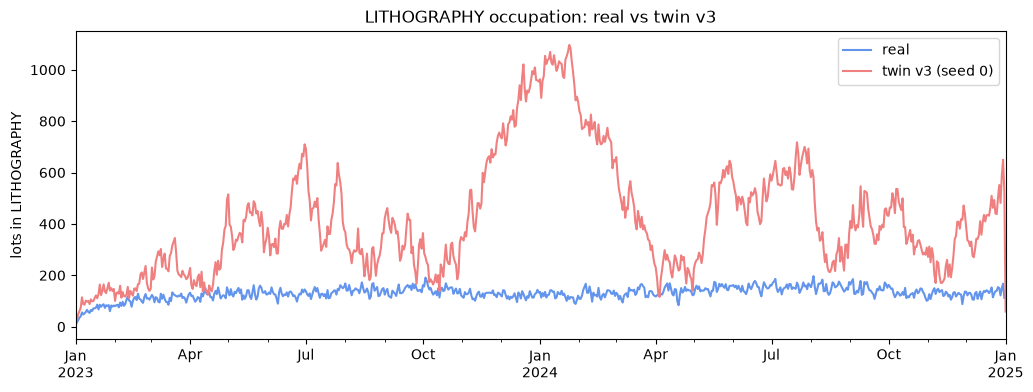

In [35]:
# Occupation curves

from wafer_twin.metrics import occupancy

real_occ = occupancy(real["QUEUE_ENTRY"], real["PROCESS_END_DATE"])
v3_occ = occupancy(sim_v3["QUEUE_ENTRY"], sim_v3["PROCESS_END_DATE"])

fig, ax = plt.subplots(figsize=(12, 4))
real_occ.resample("D").mean().plot(ax=ax, color="#6495ED", label="real")
v3_occ.resample("D").mean().plot(ax=ax, color="#F08080", label="twin v3 (seed 0)")
ax.set_ylabel("lots in LITHOGRAPHY")
ax.set_title("LITHOGRAPHY occupation: real vs twin v3")
ax.legend()
plt.show()

In [36]:
# Gaps between consecutive lots on real machines
d = real.sort_values(["MACHINE", "PROCESS_BEGIN_DATE"])
prev_end = d.groupby("MACHINE")["PROCESS_END_DATE"].shift(1)
prev_recipe = d.groupby("MACHINE")["RECIPE"].shift(1)

# time between the end of the previous lot and the start of this one, same machine
gap = (d["PROCESS_BEGIN_DATE"] - prev_end).dt.total_seconds() / 60
has_prev = prev_end.notna()

print("lots starting before the previous one ended:", (gap[has_prev] < 0).sum())
print()
changed = (d["RECIPE"] != prev_recipe)[has_prev].map({True: "recipe change", False: "same recipe"})
gap[has_prev].groupby(changed).describe().round(2)

lots starting before the previous one ended: 0



,count,mean,std,min,25%,50%,75%,max
RECIPE,,,,,,,,
recipe change,207436.0,0.81,9.30,0.0,0.0,0.0,0.0,1218.46
same recipe,406710.0,0.37,6.16,0.0,0.0,0.0,0.0,1070.70


### Takeaways :

- The twin matches reality during warm-up (Jan–Apr 2023), then the curves split:
  the real queue stays stable (~100–180 lots) while the twin makes huge waves (up to ~550 lots in Jan 2024)
- The twin is not short of capacity: its queue keeps coming back to the real level.
  Reality has a mechanism that keeps the queue stable, which the twin lacks
- With independent processing times at 99% utilization, big excursions are expected:
  the real fab is "too stable" for this kind of model
- Real machines never overlap lots, and idle gaps are tiny (median 0; mean 0.81 min after a recipe change
  vs 0.37 min otherwise): no hidden setup time between operations
- Hypothesis: real processing times depend on the load (faster when the queue is long)

## Do processing times depend on the load?

For each operation: queue size when it starts, and relative duration = duration / mean duration of its recipe.
Operations are grouped into 10 bins of queue size (warm-up excluded).
If real relative durations drop as the queue grows, processing speeds up under load.

In [37]:
def duration_vs_load(ops, occ):
    df = ops[ops["PROCESS_BEGIN_DATE"] >= "2023-04-01"].copy()

    # queue size in the workshop at the hour the op starts
    df["QUEUE_AT_START"] = occ.reindex(df["PROCESS_BEGIN_DATE"].dt.floor("h")).to_numpy()

    # 1.0 = usual duration for this recipe
    df["REL_TIME"] = df["PROCESS_TIME_MIN"] / df.groupby("RECIPE")["PROCESS_TIME_MIN"].transform("mean")

    bins = pd.qcut(df["QUEUE_AT_START"], 10, duplicates="drop")
    return df.groupby(bins, observed=True)["REL_TIME"].agg(["count", "mean", "median"])


print("REAL")
print(duration_vs_load(real, real_occ).round(3))
print()
print("TWIN v3")
print(duration_vs_load(sim_v3, v3_occ).round(3))

REAL
                 count   mean  median
QUEUE_AT_START                       
(29.999, 109.0]  56239  1.012   0.959
(109.0, 118.0]   56446  1.009   0.954
(118.0, 124.0]   51618  1.007   0.953
(124.0, 130.0]   56325  0.999   0.945
(130.0, 136.0]   59951  0.996   0.943
(136.0, 141.0]   46475  0.998   0.944
(141.0, 147.0]   52821  1.001   0.945
(147.0, 155.0]   58838  0.994   0.940
(155.0, 165.0]   50734  0.990   0.939
(165.0, 212.0]   52511  0.994   0.939

TWIN v3
                  count   mean  median
QUEUE_AT_START                        
(17.999, 220.0]  109280  1.002   0.944
(220.0, 270.0]   108240  1.002   0.945
(270.0, 320.0]   109016  0.999   0.943
(320.0, 364.0]   110346  0.999   0.940
(364.0, 410.0]   105894  0.998   0.945
(410.0, 462.0]   110110  1.003   0.947
(462.0, 530.0]   108444  0.999   0.943
(530.0, 622.0]   107006  0.997   0.942
(622.0, 782.0]   107162  0.999   0.942
(782.0, 1162.0]  108362  1.002   0.945


### Takeaways

- Real processing speeds up under load: mean relative duration goes from 1.012 (queue < 109 lots)
  to ~0.99 (queue > 155 lots), median from 0.959 to 0.939, i.e. about 2% faster when busy
- The twin shows no such effect (~1.00 in every bin), as expected since its durations ignore the queue
- ~2% is more than twice LITHOGRAPHY's spare capacity (0.8%): enough to drain a building queue,
  which explains why the real queue stays in 30–212 lots while the twin's reaches 581
- Chance alone would push the other way (slow operations make the queue grow),
  so the observed speed-up is real, and probably slightly underestimated

## Load effect on processing times

Linear fit on real operations (warm-up excluded): relative duration = a + b × lots in the workshop at start.
Saved to `params/` for the twin v4, which will multiply each Gamma draw by a + b × current load.

In [38]:
from scipy import stats

from wafer_twin.params import PARAMS_DIR

d = real[real["PROCESS_BEGIN_DATE"] >= "2023-04-01"].copy()
d["QUEUE_AT_START"] = real_occ.reindex(d["PROCESS_BEGIN_DATE"].dt.floor("h")).to_numpy()
d["REL_TIME"] = d["PROCESS_TIME_MIN"] / d.groupby("RECIPE")["PROCESS_TIME_MIN"].transform("mean")

fit = stats.linregress(d["QUEUE_AT_START"], d["REL_TIME"])
a, b = fit.intercept, fit.slope
print(f"rel_time = {a:.4f} + ({b:.6f}) x load")
print(f"slope std error: {fit.stderr:.6f}  (slope / std error = {b / fit.stderr:.1f})")
print()
for q in [50, 100, 130, 160, 200, 300]:
    print(f"load {q:>3}: x{a + b * q:.3f}")

# observed load range, the twin won't extrapolate beyond it
load_min, load_max = d["QUEUE_AT_START"].min(), d["QUEUE_AT_START"].max()
print(f"\nobserved load range: {load_min:.0f} to {load_max:.0f} lots")

pd.DataFrame({
    "parameter": ["intercept", "slope", "load_min", "load_max"],
    "value": [a, b, load_min, load_max],
}).to_csv(PARAMS_DIR / "litho_load_effect.csv", index=False)

rel_time = 1.0387 + (-0.000284) x load
slope std error: 0.000032  (slope / std error = -8.8)

load  50: x1.025
load 100: x1.010
load 130: x1.002
load 160: x0.993
load 200: x0.982
load 300: x0.953

observed load range: 30 to 212 lots


## Twin v4: + load-dependent processing speed

Same as v3, and each Gamma draw is multiplied by a + b × lots in the workshop (load clipped to 30–212).

In [40]:
from wafer_twin.simulation import load_load_effect

load_eff = load_load_effect()
print("load effect (a, b, min, max):", tuple(round(x, 6) for x in load_eff))

t = time.perf_counter()
rep_v4 = replicate(prod_v3, rec_v3, same_recipe_factor=factor_v3, load_effect=load_eff)
print(f"5 runs in {time.perf_counter() - t:.0f} s")

summary["v4_mean"] = rep_v4.mean()
summary["v4_min"] = rep_v4.min()
summary["v4_max"] = rep_v4.max()
summary[["real", "v3_mean", "v3_min", "v3_max", "v4_mean", "v4_min", "v4_max"]].round(1)

load effect (a, b, min, max): (np.float64(1.038728), np.float64(-0.000284), np.float64(30.0), np.float64(212.0))
5 runs in 79 s


,real,v3_mean,v3_min,v3_max,v4_mean,v4_min,v4_max
PRODUCT,,,,,,,
PRODUCT_0001,109.6,192.3,161.3,244.3,113.9,110.9,118.2
PRODUCT_0002,292.0,597.5,482.0,781.0,312.5,298.4,327.2
PRODUCT_0003,132.5,229.7,190.0,291.2,135.1,130.5,140.3
PRODUCT_0004,159.9,317.3,259.4,407.9,177.1,169.9,186.2
ALL,155.7,292.5,240.2,375.8,164.4,158.3,171.6


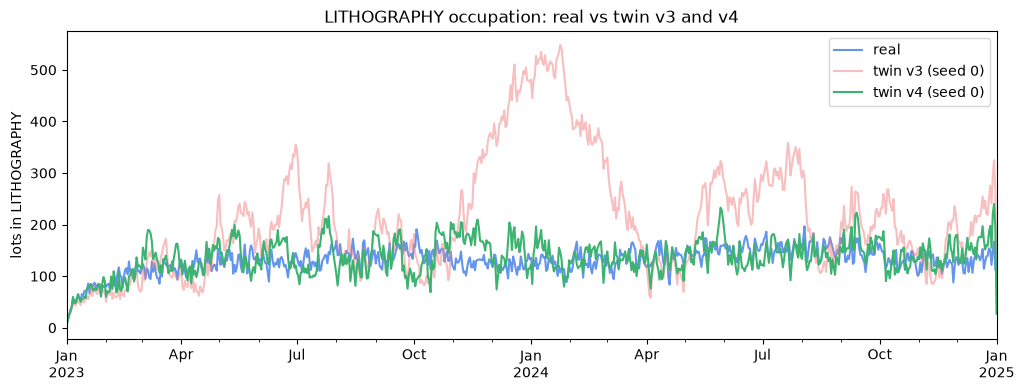

In [44]:
sim_v4 = run_twin(arrivals, machine_recipes, gamma, prod_v3, seed=0, recipe_scores=rec_v3,
                  same_recipe_factor=factor_v3, load_effect=load_eff)
v4_occ = occupancy(sim_v4["QUEUE_ENTRY"], sim_v4["PROCESS_END_DATE"])

fig, ax = plt.subplots(figsize=(12, 4))
real_occ.resample("D").mean().plot(ax=ax, color="#6495ED", label="real")
v3_occ.resample("D").mean().plot(ax=ax, color="#F08080", alpha=0.5, label="twin v3 (seed 0)")
v4_occ.resample("D").mean().plot(ax=ax, color="#3CB371", label="twin v4 (seed 0)")
ax.set_ylabel("lots in LITHOGRAPHY")
ax.set_title("LITHOGRAPHY occupation: real vs twin v3 and v4")
ax.legend()
plt.show()

### Takeaways :

- Twin v4 reproduces reality: mean waiting 164 min vs 156 min real (+6%),
  vs +88% for v3 and +180% for v1
- Per product the gap ranges from +2% (PRODUCT_0003) to +11% (PRODUCT_0004); product order is kept
  and PRODUCT_0002 still waits ~2.7× more than PRODUCT_0001, as in reality
- The twin is now stable across seeds: 158–172 min (about ±4%), vs 240–376 min for v3,
  so scenarios can be compared with a few replications
- The occupation curve follows the real one for 2 years (~100–230 lots), without the big waves of v3:
  the load effect gives the twin the self-regulation the real fab has
- Small remaining bias: the real value (156) sits just below the lowest run (158),
  so the twin slightly overestimates waiting
- Note: an earlier `sim_v3` had every lot logged twice (a temporary duplicate `log.append` picked up
  by autoreload while editing `simulation.py`). Waiting means were not affected; the curve was rerun cleanly

## Per-recipe check

A good overall mean could hide errors that cancel out between recipes.
Waiting per recipe, real vs twin v1 and v4 (seed 0; v4 varies only ~±4% between seeds).

In [46]:
# waiting per recipe: real vs v1 vs v4
recipe_check = pd.DataFrame({
    "n_machines": wait_recipe["n_machines"],
    "real": wait_recipe["real"],
    "v1": sim.groupby("RECIPE")["WAIT_MIN"].mean(),
    "v4": sim_v4.groupby("RECIPE")["WAIT_MIN"].mean(),
})
recipe_check["ratio_v1"] = recipe_check["v1"] / recipe_check["real"]
recipe_check["ratio_v4"] = recipe_check["v4"] / recipe_check["real"]

print(recipe_check[["ratio_v1", "ratio_v4"]].describe().round(2))
recipe_check.sort_values("ratio_v4", ascending=False).round(2)

       ratio_v1  ratio_v4
count     28.00     28.00
mean       1.71      1.09
std        0.67      0.06
min        0.91      0.97
25%        1.24      1.06
50%        1.51      1.10
75%        1.90      1.13
max        3.89      1.21


,n_machines,real,v1,v4,ratio_v1,ratio_v4
RECIPE_0014,7,143.14,178.28,173.49,1.25,1.21
RECIPE_0008,9,158.56,176.21,190.70,1.11,1.20
RECIPE_0004,6,255.24,404.47,298.77,1.58,1.17
RECIPE_0022,9,100.85,120.77,117.31,1.20,1.16
RECIPE_0005,12,41.79,48.67,48.38,1.16,1.16
RECIPE_0026,12,56.89,92.52,65.80,1.63,1.16
RECIPE_0027,5,258.85,1007.63,296.99,3.89,1.15
RECIPE_0010,7,77.24,70.54,86.86,0.91,1.12
RECIPE_0012,7,138.21,337.54,154.40,2.44,1.12
RECIPE_0029,8,119.86,183.43,133.56,1.53,1.11


### Takeaways :

- v1 errors were large and uneven: per-recipe ratio twin/real from 0.91 to 3.89 (median 1.51, std 0.67)
- v4 is close to reality for every recipe: ratios from 0.97 to 1.21 (median 1.10, std 0.06)
- The recipes that broke v1 are fixed: RECIPE_0027 3.89 → 1.15, RECIPE_0021 3.10 → 0.97,
  RECIPE_0016 2.52 → 1.03, RECIPE_0028 2.15 → 0.98
- Remaining bias is small and consistent: 26 of 28 recipes wait slightly too long (~+10%).
  The two furthest (RECIPE_0014, RECIPE_0008, ~+20%) are among the least used
- The good overall result does not hide compensating errors between recipes